how similar are the path weights over time

In [8]:
cm_list = ["unv1","prv1","cluster_a","cluster_b","cluster_c"]
load_dict = {"unv1":10, "prv1":10, "cluster_a":30, "cluster_b":40, "cluster_c":50}
nintervals_dict = {"unv1":8, "prv1":8, "cluster_a":48, "cluster_b":48, "cluster_c":48}
numsw = 80
npfile = "../../../evalnetpathfiles/netpath_dring_80_64_su2.np"

In [15]:
def read_npfile_into_nplist(npfile):
    netpath = list()
    for i in range(numsw):
        netpath.append(list())
        for j in range(numsw):
            netpath[i].append(list())
    with open(npfile,'r') as f:
        lines = f.readlines()
        # produce
        fromsw = 0
        tosw = 0
        for line in lines:
            if "->" not in line:
                tokens = line.split()
                fromsw = int(tokens[0])
                tosw = int(tokens[1])
            else:
                path = [fromsw]
                tokens = line.split()
                for token in tokens:
                    hops = token.split("->")
                    path.append(int(hops[1]))
                netpath[fromsw][tosw].append(path)
    return netpath

def read_pwfile_into_pwlist(pwfile,nplist):
    pwlist = list()
    for fromsw in range(numsw):
        pwlist.append(list())
        for tosw in range(numsw):
            pwlist[fromsw].append(list())
            for pid in range(len(nplist[fromsw][tosw])):
                pwlist[fromsw][tosw].append(0)
    with open(pwfile,'r') as fr:
        lines = fr.readlines()
        for line in lines:
            fromsw,tosw,pid,pw = line.split(',')
            # print(f"fromsw: {fromsw}, tosw: {tosw}, pid: {pid}, pw: {pw}")
            pwlist[int(fromsw)][int(tosw)][int(pid)] = float(pw)
    return pwlist

delta_list_dict = dict()
for cm in cm_list:
    nplist = read_npfile_into_nplist(npfile)
    delta_list = list()
    for iinterval,interval in enumerate(range(nintervals_dict[cm])):
        if iinterval==0: continue
        prevpwfile = f"../eval_main/{cm}/pwfiles/pathweight_dring_su2_{cm}_load{load_dict[cm]}_interval{interval-1}.pw"
        prevpwlist = read_pwfile_into_pwlist(prevpwfile,nplist)
        currepwfile = f"../eval_main/{cm}/pwfiles/pathweight_dring_su2_{cm}_load{load_dict[cm]}_interval{interval}.pw"
        currpwlist = read_pwfile_into_pwlist(currepwfile,nplist)
        delta = 0
        for fromsw in range(numsw):
            for tosw in range(numsw):
                if fromsw==tosw: continue
                for pid in range(len(prevpwlist[fromsw][tosw])):
                    if sum(prevpwlist[fromsw][tosw])==0:
                        prevpw = 1/len(prevpwlist[fromsw][tosw])
                    else:
                        prevpw = prevpwlist[fromsw][tosw][pid]
                    if sum(currpwlist[fromsw][tosw])==0:
                        currpw = 1/len(currpwlist[fromsw][tosw])
                    else:
                        currpw = currpwlist[fromsw][tosw][pid]
                    if prevpw!=currpw:
                        delta += (prevpw-currpw)*(prevpw-currpw)
        delta_list.append(delta)
    # print(len(delta_list))
    delta_list_dict[cm] = delta_list

7
7
47
47
47


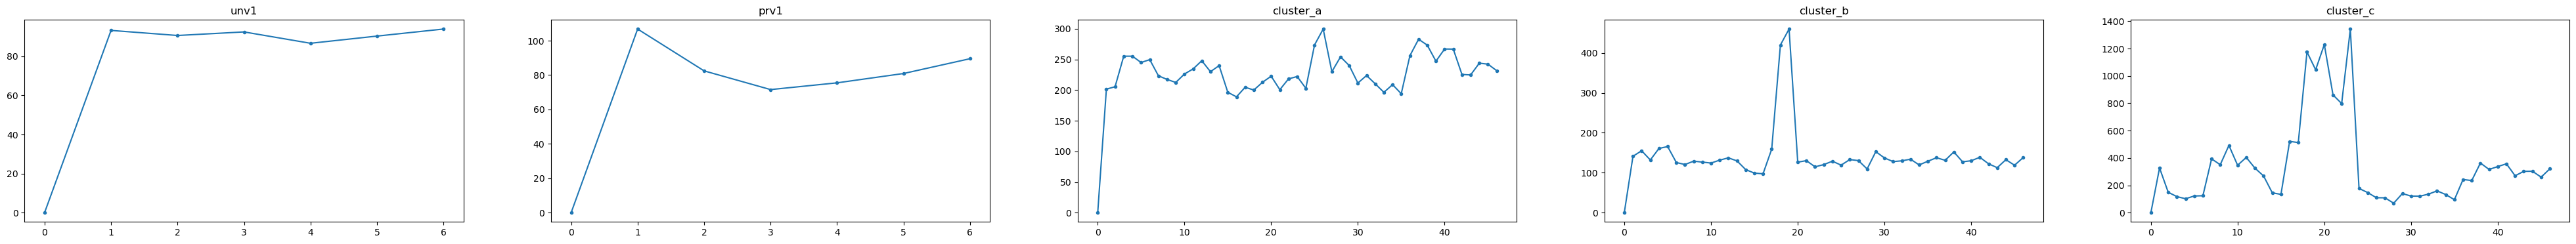

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*10, nr*4))
for ic,cm in enumerate(cm_list):
    axs[ic].plot(range(nintervals_dict[cm]-1), delta_list_dict[cm], marker='.')
    axs[ic].set_title(f"{cm}")